# PERSIAPAN

## Import library

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import logging
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv3D, MaxPooling3D,
                                     Flatten, Dense, Dropout, BatchNormalization, concatenate,
                                     GlobalAveragePooling2D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import (MobileNetV2, EfficientNetB0, ResNet50)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

2025-07-15 11:58:38.891065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752580719.253823      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752580719.358252      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Membuat fungsi utilitas logging

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    handlers=[
        logging.FileHandler("log_preprocessing_dataset.log", mode='w'), # Simpan log ke file
        logging.StreamHandler() # Tampilkan juga di layar
    ]
)

# Dapatkan instance logger untuk digunakan di seluruh skrip
logger = logging.getLogger(__name__)

logger.info("Sistem logging siap digunakan.")

## Membuat nama lead

In [3]:
lead_names = [
    'lead_I', 'lead_II', 'lead_III',
    'lead_aVR', 'lead_aVL', 'lead_aVF',
    'lead_V1', 'lead_V2', 'lead_V3',
    'lead_V4', 'lead_V5', 'lead_V6'
]

## Membuat folder output

In [4]:
def create_output_directory():
    # --- LANGKAH 1: DEFINISIKAN SEMUA NAMA FOLDER ---

    # Definisikan nama folder paling atas (root)
    folder_utama = 'data_preprocess'
    
    # Definisikan nama-nama subfolder level 1
    subfolder_utama = ['01_gray', '02_blur', '03_thres', '04_clean', '05_lead']
    
    # Definisikan nama-nama subfolder di dalam '05_lead'
    subfolder_di_dalam_lead = ['01_long', '02_short']
    
    # Definisikan nama-nama untuk 12 lead
    nama_12_lead = list(lead_names)
    
    # --- LANGKAH 2: BUAT STRUKTUR FOLDER SECARA BERTAHAP ---
    
    logger.info(f"Membuat folder utama: '{folder_utama}'")
    os.makedirs(folder_utama, exist_ok=True) # Membuat folder utama
    
    # Membuat subfolder level 1 di dalam folder_utama
    logger.info("Membuat subfolder level 1...")
    for sub in subfolder_utama:
        path = os.path.join(folder_utama, sub)
        os.makedirs(path, exist_ok=True)
    
    # Membuat subfolder level 2 di dalam '05_lead'
    logger.info("Membuat subfolder di dalam '05_lead'...")
    path_folder_lead = os.path.join(folder_utama, '05_lead')
    for sub in subfolder_di_dalam_lead:
        path = os.path.join(path_folder_lead, sub)
        os.makedirs(path, exist_ok=True)
        
    # Membuat 12 folder lead di dalam '02_short' (level 3)
    logger.info("Membuat 12 folder lead...")
    path_folder_short = os.path.join(path_folder_lead, '02_short')
    for nama_lead in nama_12_lead:
        path = os.path.join(path_folder_short, nama_lead)
        os.makedirs(path, exist_ok=True)
    
    logger.info("\n✅ Struktur folder telah berhasil dibuat!")

In [5]:
create_output_directory()

# Langkah 1: Proses dataset

## Membuat fungsi proses satu gambar ekg

In [6]:
def preprocess_single_ecg_dual_output(image_path):
    try:
        gambar_asli = cv2.imread(image_path)
        nama_file = os.path.basename(image_path)
        if gambar_asli is None:
            print(f"  - Gagal memuat gambar: {image_path}")
            return None, None
        
        # --- Tahap 1 & 2: Preprocessing dan Pembersihan ---
        gambar_gray = cv2.cvtColor(gambar_asli, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(os.path.join('data_preprocess/01_gray', nama_file), gambar_gray)
        
        gambar_blurred = cv2.GaussianBlur(gambar_gray, (5, 5), 0)
        cv2.imwrite(os.path.join('data_preprocess/02_blur', nama_file), gambar_blurred)
        
        ret, gambar_thresholded = cv2.threshold(gambar_blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        cv2.imwrite(os.path.join('data_preprocess/03_thres', nama_file), gambar_thresholded)
        
        kernel = np.ones((3,3), np.uint8)
        gambar_cleaned = cv2.morphologyEx(gambar_thresholded, cv2.MORPH_OPEN, kernel)
        cv2.imwrite(os.path.join('data_preprocess/04_clean', nama_file), gambar_cleaned)
        
        # --- Tahap 3: Deteksi Kontur Blok Sinyal ---
        contours, _ = cv2.findContours(gambar_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        kontur_valid = []
        area_minimum = 5000
        for c in contours:
            if cv2.contourArea(c) > area_minimum:
                kontur_valid.append((c, cv2.boundingRect(c)))
        
        if len(kontur_valid) < 1:
            print(f"  - Tidak ditemukan kontur blok sinyal utama pada: {image_path}")
            return None
        
        # --- Tahap 4: Crop Blok Sinyal Utama (Terbesar) ---
        kontur_terbesar, bbox_terbesar = max(kontur_valid, key=lambda item: cv2.contourArea(item[0]))
        kontur_terbawah, bbox_terbawah = max(kontur_valid, key=lambda item: item[1][1])
        
        padding_x = 5
        padding_y = 0
        
        # Crop 12 lead
        (x, y, w, h) = bbox_terbesar
        crop_12_lead_cleaned = gambar_cleaned[y-padding_y : y+h+padding_y, x-padding_x : x+w+padding_x]
        # print(crop_12_lead_cleaned)
        
        # Crop long lead
        (x, y, w, h) = bbox_terbawah
        crop_long_lead_cleaned = gambar_cleaned[y-padding_y : y+h+padding_y, x-padding_x : x+w+padding_x]

        UKURAN_STANDAR_BLOK = (1980, 786)
    
        # print(f"  - Ukuran blok 12-lead asli: {crop_12_lead_cleaned.shape[1]}x{crop_12_lead_cleaned.shape[0]}")
        crop_12_lead_standardized = cv2.resize(crop_12_lead_cleaned, UKURAN_STANDAR_BLOK, interpolation=cv2.INTER_AREA)
        # print(f"  - Ukuran blok 12-lead setelah distandarisasi: {crop_12_lead_standardized.shape[1]}x{crop_12_lead_standardized.shape[0]}")
        
        # --- Tahap 5: Pemisahan 12-Lead Manual ---
        # Format: [ (x1, y1, x2, y2), ... ] untuk setiap lead
        min_gap = 487
        kolom_mulai_x = [6, 502, 993, 1485]
        kolom_akhir_x = [kolom_mulai_x[0] + min_gap,
                          kolom_mulai_x[1] + min_gap,
                          kolom_mulai_x[2] + min_gap,
                          kolom_mulai_x[3] + min_gap]
        
        koordinat_leads = [
            # Kolom 1
            (kolom_mulai_x[0], 0, kolom_akhir_x[0], 262),  # Koordinat untuk Lead I
            (kolom_mulai_x[0], 262, kolom_akhir_x[0], 524),  # Koordinat untuk Lead II
            (kolom_mulai_x[0], 524, kolom_akhir_x[0], 786),  # Koordinat untuk Lead III
            # Kolom 2
            (kolom_mulai_x[1], 0, kolom_akhir_x[1], 262),  # Koordinat untuk Lead aVR
            (kolom_mulai_x[1], 262, kolom_akhir_x[1], 524), # Koordinat untuk Lead aVL
            (kolom_mulai_x[1], 524, kolom_akhir_x[1], 786), # Koordinat untuk Lead aVF
            # Kolom 3
            (kolom_mulai_x[2], 0, kolom_akhir_x[2], 262),  # Koordinat untuk Lead V1
            (kolom_mulai_x[2], 262, kolom_akhir_x[2], 524), # Koordinat untuk Lead V2
            (kolom_mulai_x[2], 524, kolom_akhir_x[2], 786), # Koordinat untuk Lead V3
            # Kolom 4
            (kolom_mulai_x[3], 0, kolom_akhir_x[3], 262), # Koordinat untuk Lead V4
            (kolom_mulai_x[3], 262, kolom_akhir_x[3], 524),# Koordinat untuk Lead V5
            (kolom_mulai_x[3], 524, kolom_akhir_x[3], 786) # Koordinat untuk Lead V6
        ]
        
        # Urutan pemisahan yang disesuaikan dengan layout EKG
        urutan_layout = [
            (0,0), (1,0), (2,0), # Kolom 1
            (0,1), (1,1), (2,1), # Kolom 2
            (0,2), (1,2), (2,2), # Kolom 3
            (0,3), (1,3), (2,3)  # Kolom 4
        ]
        
        list_hasil_manual = []
        for (baris, kolom) in urutan_layout:
            idx = baris * 4 + kolom
            (x1, y1, x2, y2) = koordinat_leads[idx]
            potongan = crop_12_lead_standardized[y1:y2, x1:x2]
            list_hasil_manual.append(potongan)
        
        UKURAN_TARGET_12_LEAD = (224, 144) # (lebar, tinggi)
        nama_12_lead = list(lead_names)
        list_12_lead_resized = []
        folder_tujuan_12_leads = os.path.join('data_preprocess', '05_lead', '02_short')
        folder_tujuan_long_lead = os.path.join('data_preprocess', '05_lead', '01_long')
        # print(f"Hasil resize setiap lead akan disimpan di: '{folder_tujuan_leads}'")

        for i, potongan in enumerate(list_hasil_manual):
    
            # 1. Lakukan resize
            potongan_resized = cv2.resize(potongan, UKURAN_TARGET_12_LEAD, interpolation=cv2.INTER_AREA)
            
            # 2. Tambahkan hasil resize ke dalam list
            list_12_lead_resized.append(potongan_resized)
            
            # 3. Buat nama file yang unik untuk setiap lead
            folder_tujuan_lengkap = os.path.join(folder_tujuan_12_leads, nama_12_lead[i])
            nama_file_output = f"{nama_file}"
            
            # 4. Bangun path lengkap
            path_lengkap_output = os.path.join(folder_tujuan_lengkap, nama_file_output)
            
            # 5. Simpan gambar yang sudah di-resize
            cv2.imwrite(path_lengkap_output, potongan_resized)
        
        # print(f"\n{len(list_12_lead_resized)} gambar lead telah di-resize dan disimpan.")
        
        if len(list_12_lead_resized) != 12: return None, None
        volume_3d_ekg = np.stack(list_12_lead_resized, axis=0)
        
        # --- Tahap 5B: Proses Long-Lead ---
        UKURAN_TARGET_LONG_LEAD = (898, 141) # (lebar, tinggi)
        long_lead_resized = cv2.resize(crop_long_lead_cleaned, UKURAN_TARGET_LONG_LEAD, interpolation=cv2.INTER_AREA)
        path_lengkap_long = os.path.join(folder_tujuan_long_lead, f'{nama_file}')
        cv2.imwrite(path_lengkap_long, long_lead_resized)
        
        return volume_3d_ekg, long_lead_resized

    except Exception as e:
        # print(f"  - Terjadi error saat memproses {image_path}: {e}")
        return None, None

## Membuat proses batch

In [7]:
path_dataset_utama = "/kaggle/input/dataset-12plus1"
X_12_lead_data = []
X_long_lead_data = []
y_labels = []

if not os.path.exists(path_dataset_utama):
    print(f"Error: Direktori '{path_dataset_utama}' tidak ditemukan.")
else:
    for nama_kategori in sorted(os.listdir(path_dataset_utama)):
        path_kategori = os.path.join(path_dataset_utama, nama_kategori)
        if os.path.isdir(path_kategori):
            print(f"\nMemproses kategori: '{nama_kategori}'...")
            for nama_file in os.listdir(path_kategori):
                path_file_gambar = os.path.join(path_kategori, nama_file)
        
                # Fungsi sekarang mengembalikan DUA nilai
                volume, long_lead = preprocess_single_ecg_dual_output(path_file_gambar)
                
                # Hanya simpan jika KEDUA-DUANYA berhasil diproses
                if volume is not None and long_lead is not None:
                    X_12_lead_data.append(volume)
                    X_long_lead_data.append(long_lead)
                    y_labels.append(nama_kategori)
                
                    # print(f"  - Berhasil memproses: {nama_file}")
        
    print("\n=====================================")
    print("SELURUH DATASET TELAH SELESAI DIPROSES.")
    print(f"Total gambar yang berhasil diproses: {len(y_labels)}")
    print("=====================================")

# --- TAHAP FINAL: KONVERSI KE NUMPY ARRAY & SIMPAN KE FILE TERPISAH ---
if y_labels:
    # Konversi dan simpan data 12-lead
    X_12_lead_final = np.array(X_12_lead_data)
    np.save('X_12_lead_processed.npy', X_12_lead_final)
    print(f"\nData 12-Lead (volume) disimpan ke 'X_12_lead_processed.npy'")
    print(f"Bentuk (shape) data: {X_12_lead_final.shape}")
    
    # Konversi dan simpan data long-lead
    X_long_lead_final = np.array(X_long_lead_data)
    np.save('X_long_lead_processed.npy', X_long_lead_final)
    print(f"\nData Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'")
    print(f"Bentuk (shape) data: {X_long_lead_final.shape}")
    
    # Konversi dan simpan label (cukup satu kali karena sama untuk keduanya)
    y_final = np.array(y_labels)
    np.save('y_labels.npy', y_final)
    print(f"\nLabel disimpan ke 'y_labels.npy'")
    print(f"Bentuk (shape) data: {y_final.shape}")


Memproses kategori: 'abnormal'...

Memproses kategori: 'history_myocardial_infaction'...

Memproses kategori: 'myocardial_infarction'...

Memproses kategori: 'normal'...

SELURUH DATASET TELAH SELESAI DIPROSES.
Total gambar yang berhasil diproses: 928

Data 12-Lead (volume) disimpan ke 'X_12_lead_processed.npy'
Bentuk (shape) data: (928, 12, 144, 224)

Data Long-Lead (gambar) disimpan ke 'X_long_lead_processed.npy'
Bentuk (shape) data: (928, 141, 898)

Label disimpan ke 'y_labels.npy'
Bentuk (shape) data: (928,)


## Load data gambar yang sudah diproses

In [8]:
def load_and_prepare_dataset(path_x12, path_xlong, path_y):
    try:
        X_12_lead = np.load(path_x12)
        X_long_lead = np.load(path_xlong)
        y_str = np.load(path_y) # Label masih dalam bentuk string
    except FileNotFoundError:
        print(f"Error: Salah satu atau lebih file tidak ditemukan. Periksa kembali path file.")
        return None, None, None, None, None
    else:
        print("Data berhasil dimuat.")
        print(f"Bentuk X_12_lead: {X_12_lead.shape}")
        print(f"Bentuk X_long_lead: {X_long_lead.shape}")
        print(f"Bentuk y_str: {y_str.shape}")
        
        # --- ENCODING LABEL (STRING KE ANGKA) ---
        print("\nMelakukan encoding pada label...")
        encoder = LabelEncoder()
        y_encoded = encoder.fit_transform(y_str)
        num_classes = len(encoder.classes_)
        
        print(f"Jumlah kelas: {num_classes}")
        print("Pemetaan Label:")
        for i, kelas in enumerate(encoder.classes_):
            print(f"- {kelas} -> {i}")
            
        return X_12_lead, X_long_lead, y_encoded, num_classes, encoder

## Membagi dataset untuk data latih, validasi, dan tes

In [9]:
# 1. Definisikan path ke file-file Anda
path_12_lead = 'X_12_lead_processed.npy'
path_long_lead = 'X_long_lead_processed.npy'
path_label = 'y_labels.npy'

# 2. Panggil fungsi untuk memuat dan mempersiapkan semua data
X_12, X_long, y, NUM_CLASSES, encoder = load_and_prepare_dataset(
    path_12_lead, 
    path_long_lead, 
    path_label
)

Data berhasil dimuat.
Bentuk X_12_lead: (928, 12, 144, 224)
Bentuk X_long_lead: (928, 141, 898)
Bentuk y_str: (928,)

Melakukan encoding pada label...
Jumlah kelas: 4
Pemetaan Label:
- abnormal -> 0
- history_myocardial_infaction -> 1
- myocardial_infarction -> 2
- normal -> 3


In [10]:
def pembagian_data(X_12_lead, X_long_lead, y, test_size=0.20, val_size=0.20, random_state=42):
    # Tahap 1: Pisahkan data menjadi training-pool dan test set
    # test_size di sini adalah persentase dari keseluruhan data
    X_12_train_pool, X_12_test, \
    X_long_train_pool, X_long_test, \
    y_train_pool, y_test = train_test_split(
        X_12_lead, X_long_lead, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Tahap 2: Pisahkan training-pool menjadi train set final dan validation set
    # val_size di sini adalah persentase dari sisa data (train_pool)
    X_12_train, X_12_val, \
    X_long_train, X_long_val, \
    y_train, y_val = train_test_split(
        X_12_train_pool, X_long_train_pool, y_train_pool,
        test_size=val_size,
        random_state=random_state,
        stratify=y_train_pool
    )
    
    # Kembalikan semua bagian data
    return (X_12_train, X_12_val, X_12_test,
            X_long_train, X_long_val, X_long_test,
            y_train, y_val, y_test)

In [11]:
def reshape_data_for_2d_model(data_12_lead, data_long_lead):
    print(f"  - Mereshape data 12-lead dari {data_12_lead.shape}...")
    # Transpose dimensi agar menjadi (N, H, W, 12)
    reshaped_12_lead = data_12_lead.transpose(0, 2, 3, 1)
    print(f"    -> Bentuk baru: {reshaped_12_lead.shape}")

    print(f"  - Mereshape data long-lead dari {data_long_lead.shape}...")
    # Tambahkan dimensi channel di akhir agar menjadi (N, H, W, 1)
    reshaped_long_lead = np.expand_dims(data_long_lead, axis=-1)
    print(f"    -> Bentuk baru: {reshaped_long_lead.shape}")
    
    return reshaped_12_lead, reshaped_long_lead

In [12]:
(X_12_train, X_12_val, X_12_test,
 X_long_train, X_long_val, X_long_test,
 y_train, y_val, y_test) = pembagian_data(
                                X_12, 
                                X_long, 
                                y,
                                test_size=0.20, # 20% untuk data tes
                                val_size=0.25   # 25% dari sisa 80% data latih -> 20% dari total data
                            )

# # --- Verifikasi Hasil Akhir ---
print("\n--- UKURAN DATASET FINAL ---")
print(f"Jumlah Data Latih (Train)    : {len(y_train)} sampel (~{len(y_train)/len(y)*100:.0f}%)")
print(f"Jumlah Data Validasi (Validation): {len(y_val)} sampel (~{len(y_val)/len(y)*100:.0f}%)")
print(f"Jumlah Data Tes (Test)       : {len(y_test)} sampel (~{len(y_test)/len(y)*100:.0f}%)")
print("--------------------------------")

# # Jangan lupa menambahkan dimensi channel untuk input CNN jika belum
# X_12_train = np.expand_dims(X_12_train, axis=-1)
# X_12_val = np.expand_dims(X_12_val, axis=-1)
# X_12_test = np.expand_dims(X_12_test, axis=-1)

# X_long_train = np.expand_dims(X_long_train, axis=-1)
# X_long_val = np.expand_dims(X_long_val, axis=-1)
# X_long_test = np.expand_dims(X_long_test, axis=-1)

# --- LANGKAH 4 (KRUSIAL): MENYIAPKAN BENTUK DATA UNTUK MODEL 2D ---
# Pastikan Anda menjalankan blok ini dengan benar!

print("\nMelakukan reshape data untuk model 2D...")
# Reshape data training
print("\n1. Memproses data training...")
X_12_train_2d, X_long_train_2d = reshape_data_for_2d_model(X_12_train, X_long_train)

# Reshape data validasi
print("\n2. Memproses data validasi...")
X_12_val_2d, X_long_val_2d = reshape_data_for_2d_model(X_12_val, X_long_val)

# Reshape data tes
print("\n3. Memproses data tes...")
X_12_test_2d, X_long_test_2d = reshape_data_for_2d_model(X_12_test, X_long_test)


--- UKURAN DATASET FINAL ---
Jumlah Data Latih (Train)    : 556 sampel (~60%)
Jumlah Data Validasi (Validation): 186 sampel (~20%)
Jumlah Data Tes (Test)       : 186 sampel (~20%)
--------------------------------

Melakukan reshape data untuk model 2D...

1. Memproses data training...
  - Mereshape data 12-lead dari (556, 12, 144, 224)...
    -> Bentuk baru: (556, 144, 224, 12)
  - Mereshape data long-lead dari (556, 141, 898)...
    -> Bentuk baru: (556, 141, 898, 1)

2. Memproses data validasi...
  - Mereshape data 12-lead dari (186, 12, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 12)
  - Mereshape data long-lead dari (186, 141, 898)...
    -> Bentuk baru: (186, 141, 898, 1)

3. Memproses data tes...
  - Mereshape data 12-lead dari (186, 12, 144, 224)...
    -> Bentuk baru: (186, 144, 224, 12)
  - Mereshape data long-lead dari (186, 141, 898)...
    -> Bentuk baru: (186, 141, 898, 1)


# Langkah 2: Membuat model

## Membuat satu fungsi untuk menggunakan salah satu model yang sudah tersedia

In [13]:
def create_multi_input_transfer_model(input_shape_short, input_shape_long, num_classes, model_name='EfficientNetB0'):

    # Fungsi pembantu untuk membuat satu cabang lengkap sebagai sebuah Model
    def build_branch(input_shape, base_model_name, branch_name):
        # Input untuk cabang ini
        branch_input = Input(shape=input_shape, name=f'input_{branch_name}')

        # Lapisan adaptasi
        adapter = Conv2D(3, (1, 1), padding='same', activation='relu', name=f'adapter_{branch_name}')(branch_input)

        # Tentukan model dasar TANPA parameter 'name' agar download berhasil
        if base_model_name == 'MobileNetV2':
            base_model = MobileNetV2(
                input_shape=input_shape[:2] + (3,), 
                include_top=False, 
                weights='imagenet'
            )
        elif base_model_name == 'EfficientNetB0':
            base_model = EfficientNetB0(
                input_shape=input_shape[:2] + (3,), 
                include_top=False, 
                weights='imagenet'
            )
        elif base_model_name == 'ResNet50':
            base_model = ResNet50(
                input_shape=input_shape[:2] + (3,), 
                include_top=False, 
                weights='imagenet'
            )
        else:
            raise ValueError("Nama model tidak didukung.")

        base_model.trainable = False

        features = base_model(adapter, training=False)
        features = GlobalAveragePooling2D(name=f'gap_{branch_name}')(features)

        # Kembalikan seluruh cabang sebagai satu Model Keras
        return Model(inputs=branch_input, outputs=features, name=branch_name)

    # --- Buat dua model cabang yang terpisah ---
    branch_short = build_branch(input_shape_short, model_name, 'short_lead_branch')
    branch_long = build_branch(input_shape_long, model_name, 'long_lead_branch')

    # --- Definisikan input untuk model utama ---
    input_short = Input(shape=input_shape_short, name='input_short_lead')
    input_long = Input(shape=input_shape_long, name='input_long_lead')

    # --- Gunakan model cabang sebagai lapisan ---
    features_short = branch_short(input_short)
    features_long = branch_long(input_long)

    # --- Penggabungan (Merge) ---
    gabungan = concatenate([features_short, features_long])

    # --- Kepala Klasifikasi ---
    x = Dense(256, activation='relu')(gabungan)
    x = Dropout(0.5)(x)
    output_final = Dense(num_classes, activation='softmax')(x)

    # Buat model akhir
    model = Model(inputs=[input_short, input_long], outputs=output_final)
    return model

## Menyiapkan input yang akan digunakan model

In [14]:
# Dapatkan bentuk input dari data yang sudah di-reshape
input_shape_short = X_12_train_2d.shape[1:]
input_shape_long = X_long_train_2d.shape[1:]

# Langkah 3: Melatih Model

## Melatih model MobileNetV2

### Membuat model dan debug isi model

In [15]:
# Pilih model Anda, misalnya 'MobileNetV2'
model_mobile = create_multi_input_transfer_model(
  input_shape_short, input_shape_long, NUM_CLASSES, model_name='MobileNetV2'
)
model_mobile.summary()

I0000 00:00:1752580837.578139      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1752580837.578882      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/tmp/ipykernel_19/1727909786.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_short_lead          │ (None, 144, 224, 12)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_long_lead           │ (None, 141, 898, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ short_lead_branch         │ (None, 1280)           │      2,258,023 │ input_short_lead[0][0] │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ long_lead_branch          │ (None, 1280)           │      2,257,990 │ input_long_lead[0][0]  │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 2560)           │              0 │ short_lead_branch[0][… │
│                           │                        │                │ long_lead_branch[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        655,616 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 4)              │          1,028 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,172,657 (19.73 MB)

 Trainable params: 656,689 (2.51 MB)

 Non-trainable params: 4,515,968 (17.23 MB)

### Melatih model

In [16]:
# --- KOMPILASI DAN LATIH MODEL ---
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
);

print("\nMemulai pelatihan model MobileNetV2...")
history = model_mobile.fit(
    {'input_short_lead': X_12_train_2d, 'input_long_lead': X_long_train_2d},
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=({'input_short_lead': X_12_val_2d, 'input_long_lead': X_long_val_2d}, y_val),
    verbose=1,
    callbacks=[early_stopping_callback]
)


Memulai pelatihan model MobileNetV2...
Epoch 1/50


I0000 00:00:1752580855.758300      63 service.cc:148] XLA service 0x7bc5f081c2b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752580855.759902      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1752580855.759945      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1752580857.531010      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1752580862.202915      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752580862.439406      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1752580873.658025      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most onc

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3939 - loss: 1.6267

E0000 00:00:1752580879.831087      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752580880.008863      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.3940 - loss: 1.6226

E0000 00:00:1752580898.540276      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1752580898.760621      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/18 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.3941 - loss: 1.6190 - val_accuracy: 0.6398 - val_loss: 0.9221
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.5575 - loss: 1.0902 - val_accuracy: 0.7258 - val_loss: 0.7418
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.6524 - loss: 0.8197 - val_accuracy: 0.7688 - val_loss: 0.6546
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.6919 - loss: 0.7304 - val_accuracy: 0.7796 - val_loss: 0.5909
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.7850 - loss: 0.6185 - val_accuracy: 0.7849 - val_loss: 0.5341
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.8264 - loss: 0.5067 - val_accuracy: 0.8280 - val_loss: 0.4959
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 200ms/step - accuracy: 0.8011 - loss: 0.5011 - val_accuracy: 0.8495 - val_loss: 0.4652
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.8570 - loss: 0.4267 - val_accuracy: 0.8333 - val_lo

# Langkah 4: Evaluasi

## Evaluasi model dengan cara membuat confusion matrix

In [17]:
def simpan_laporan_kinerja(history, model, X_test, y_test, nama_model, folder_tujuan='hasil_evaluasi'):
    try:
        print(f"\n--- Membuat Laporan Kinerja untuk: {nama_model} ---")

        # --- LANGKAH 1: EKSTRAK METRIK DARI DATA VALIDASI ---
        val_accuracy_terbaik = np.max(history.history['val_accuracy'])
        val_loss_terbaik = np.min(history.history['val_loss'])
        epoch_terbaik = np.argmin(history.history['val_loss']) + 1

        # --- LANGKAH 2: EVALUASI PADA DATA TES ---
        loss_tes, akurasi_tes = model.evaluate(X_test, y_test, verbose=0)

        # --- LANGKAH 3: BUAT STRING LAPORAN LENGKAP ---
        laporan_teks = (
            f"Laporan Kinerja Model: {nama_model}\n"
            f"================================================\n\n"
            f"METRIK PADA DATA VALIDASI (selama pelatihan):\n"
            f"--------------------------------------------\n"
            f"Akurasi Validasi Tertinggi: {val_accuracy_terbaik:.4f}\n"
            f"Loss Validasi Terendah    : {val_loss_terbaik:.4f}\n"
            f"Dicapai pada Epoch          : {epoch_terbaik}\n\n"
            f"METRIK PADA DATA TES (evaluasi akhir):\n"
            f"----------------------------------------\n"
            f"Akurasi Tes Final: {akurasi_tes:.4f}\n"
            f"Loss Tes Final   : {loss_tes:.4f}\n"
        )
        
        # Cetak laporan ke konsol
        print(laporan_teks)

        # --- LANGKAH 4: SIMPAN LAPORAN KE FILE ---
        # Pastikan folder ada
        os.makedirs(folder_tujuan, exist_ok=True)
        
        # Buat nama file yang unik
        nama_file_output = f'kinerja_{nama_model.lower()}.txt'
        path_lengkap = os.path.join(folder_tujuan, nama_file_output)
        
        # Tulis ke file
        with open(path_lengkap, 'w') as f:
            f.write(laporan_teks)
            
        print(f"\n✅ Laporan kinerja telah disimpan di: '{path_lengkap}'")

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan kinerja: {e}")


In [18]:
def prediksi(model, data_tes, label_tes):
    y_pred_probs = model.predict(data_tes)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    data_confusion_matrix = confusion_matrix(label_tes, y_pred_classes)

    return data_confusion_matrix, y_pred_classes

In [19]:
cm, y_pred_classes = prediksi(model_mobile, [X_12_test_2d, X_long_test_2d], y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


In [20]:
simpan_laporan_kinerja(
    history=history,
    model=model_mobile, # Gunakan variabel model yang baru saja dilatih
    X_test=[X_12_test_2d, X_long_test_2d], # Berikan data tes dalam bentuk list
    y_test=y_test, # Label tes
    nama_model='MobileNetV2 12+1', # Beri nama yang jelas
)


--- Membuat Laporan Kinerja untuk: MobileNetV2 12+1 ---
Laporan Kinerja Model: MobileNetV2 12+1

METRIK PADA DATA VALIDASI (selama pelatihan):
--------------------------------------------
Akurasi Validasi Tertinggi: 0.9032
Loss Validasi Terendah    : 0.2674
Dicapai pada Epoch          : 31

METRIK PADA DATA TES (evaluasi akhir):
----------------------------------------
Akurasi Tes Final: 0.9570
Loss Tes Final   : 0.1663


✅ Laporan kinerja telah disimpan di: 'hasil_evaluasi/kinerja_mobilenetv2 12+1.txt'


In [21]:
def menampilkan_dan_menyimpan_confusion_matrix(cm, nama_model='MobileNetV2'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f'Confusion Matrix - Preproses 12 + 1 - {nama_model}')
    plt.ylabel('Kelas Asli (True Label)')
    plt.xlabel('Kelas Prediksi (Predicted Label)')
    
    nama_file_output = f'confusion_matrix_{nama_model.lower()}_12plus1.png'
    plt.savefig(nama_file_output, dpi=300, bbox_inches='tight')
    print(f"\nPlot confusion matrix telah disimpan sebagai: '{nama_file_output}'")
    
    plt.show()


Plot confusion matrix telah disimpan sebagai: 'confusion_matrix_mobilenetv2_12plus1.png'


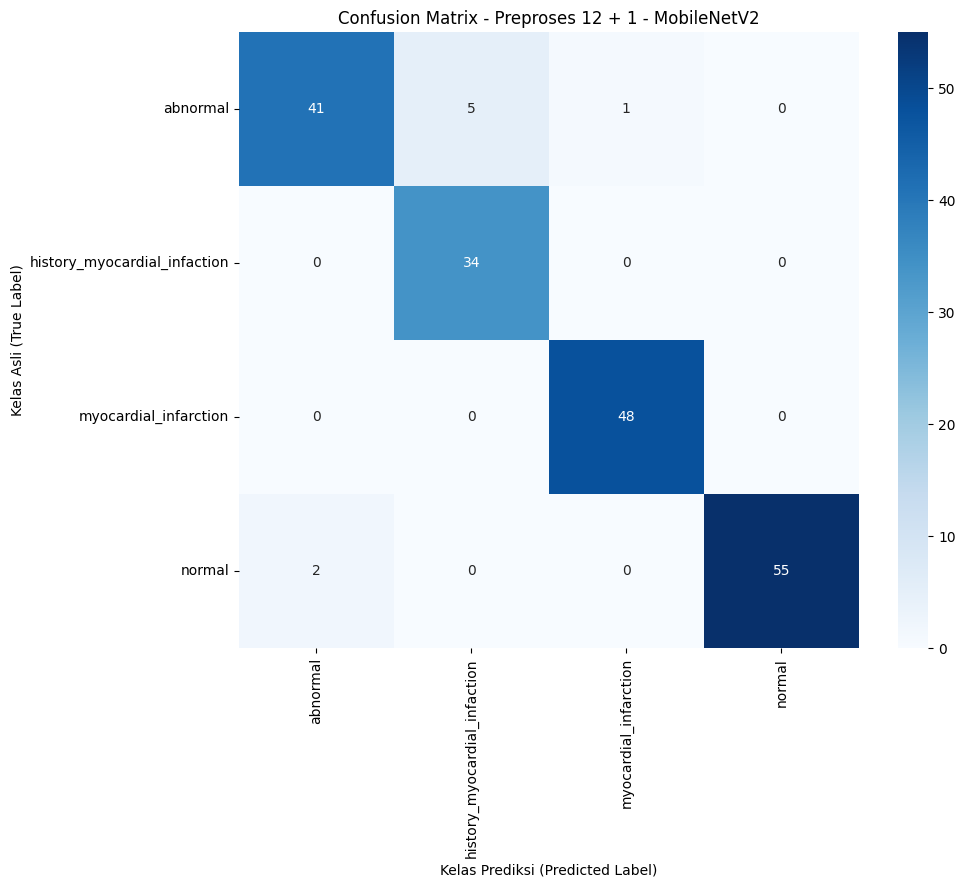

In [22]:
menampilkan_dan_menyimpan_confusion_matrix(cm, 'MobileNetV2')

## Evaluasi model dengan cara membuat classification report

In [23]:
def ubah_format_onehot(label):
    if label.ndim > 1:
        y_test_classes = np.argmax(label, axis=1)
    else:
        y_test_classes = y_test

    return y_test_classes

In [24]:
def generate_and_save_classification_report(y_true, y_pred, encoder, report_filename):
    try:
        # --- Persiapan Label ---
        # Jika y_true dalam format one-hot, ubah kembali ke format integer
        if y_true.ndim > 1 and y_true.shape[1] > 1:
            y_true_classes = np.argmax(y_true, axis=1)
        else:
            y_true_classes = y_true # Jika sudah integer

        # Dapatkan nama kelas dari encoder untuk pelabelan laporan
        target_names = encoder.classes_

        # --- Buat dan Cetak Laporan ---
        print("\nLaporan Klasifikasi (Classification Report):")
        print("======================================================")
        
        report = classification_report(y_true_classes, y_pred, target_names=target_names, digits=4)
        print(report)

        # --- Simpan laporan ke file .txt ---
        # Pastikan direktori ada (jika perlu)
        # folder_tujuan = os.path.dirname(report_filename)
        # os.makedirs(folder_tujuan, exist_ok=True)

        with open(report_filename, 'w') as f:
            f.write(f"Laporan Klasifikasi untuk Model\n")
            f.write("================================\n\n")
            f.write(report)
        
        print(f"\n✅ Laporan juga telah disimpan ke file: '{report_filename}'")
        
        return report

    except Exception as e:
        print(f"❌ Terjadi error saat membuat laporan: {e}")
        return None

In [25]:
# Tentukan nama file laporan yang unik untuk setiap model
nama_file_laporan_mobilenet= 'classification_report_MobileNetV2.txt'

# Panggil fungsi untuk menghasilkan dan menyimpan laporan
laporan_resnet = generate_and_save_classification_report(
    y_true=y_test,
    y_pred=y_pred_classes,
    encoder=encoder,
    report_filename=nama_file_laporan_mobilenet
)


Laporan Klasifikasi (Classification Report):
                              precision    recall  f1-score   support

                    abnormal     0.9535    0.8723    0.9111        47
history_myocardial_infaction     0.8718    1.0000    0.9315        34
       myocardial_infarction     0.9796    1.0000    0.9897        48
                      normal     1.0000    0.9649    0.9821        57

                    accuracy                         0.9570       186
                   macro avg     0.9512    0.9593    0.9536       186
                weighted avg     0.9595    0.9570    0.9569       186


✅ Laporan juga telah disimpan ke file: 'classification_report_MobileNetV2.txt'
